Import necessary labraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy import stats

In [2]:
# load the dataset

df = pd.read_csv('/content/diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
#checking the number of rows and columns
df.shape

(768, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
df.columns.duplicated()

array([False, False, False, False, False, False, False, False, False])

In [9]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
763,False
764,False
765,False
766,False


In [10]:
print(df['Glucose'].dtype)

int64


In [11]:
df['Glucose'].isin([0]).sum()

np.int64(5)

In [12]:
print(df.duplicated().sum())

0


Check for zero values and replace with median if any

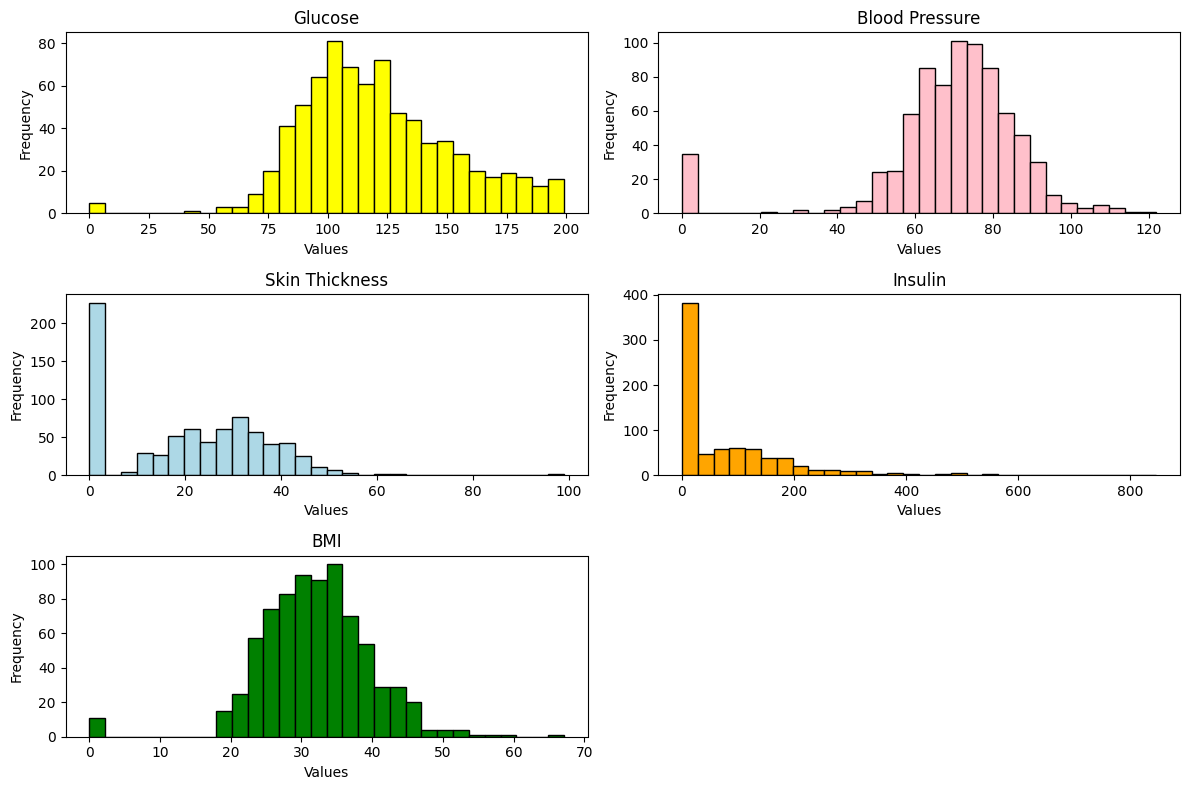

In [13]:
import matplotlib.pyplot as plt

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 8))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot each histogram
axes[0].hist(df["Glucose"], bins=30, color='yellow', edgecolor='black')
axes[0].set_title('Glucose')

axes[1].hist(df["BloodPressure"], bins=30, color='pink', edgecolor='black')
axes[1].set_title('Blood Pressure')

axes[2].hist(df["SkinThickness"], bins=30, color='lightblue', edgecolor='black')
axes[2].set_title('Skin Thickness')

axes[3].hist(df["Insulin"], bins=30, color='orange', edgecolor='black')
axes[3].set_title('Insulin')

axes[4].hist(df["BMI"], bins=30, color='green', edgecolor='black')
axes[4].set_title('BMI')

# (Optional) Turn off any unused subplot
axes[5].axis('off')

# Add common labels
for ax in axes[:-1]:
    ax.set_xlabel('Values')
    ax.set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()


In [14]:
# df['Glucose'] = df['Glucose'].replace(0, np.nan)

In [15]:
# x = df["Glucose"].median()

In [16]:
# df['Glucose'].fillna(x, inplace=True)

In [17]:
df['Glucose'].head()
print(df['Glucose'].dtype)

int64


In [18]:
df['Glucose'].unique()[:20]

array([148,  85, 183,  89, 137, 116,  78, 115, 197, 125, 110, 168, 139,
       189, 166, 100, 118, 107, 103, 126])

In [19]:
# df['Glucose'] = pd.to_numeric(df['Glucose'], errors='coerce')

(array([ 5.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  3.,  3.,  9., 20., 41.,
        51., 64., 81., 69., 61., 72., 47., 44., 33., 34., 28., 20., 17.,
        19., 17., 13., 16.]),
 array([  0.        ,   6.63333333,  13.26666667,  19.9       ,
         26.53333333,  33.16666667,  39.8       ,  46.43333333,
         53.06666667,  59.7       ,  66.33333333,  72.96666667,
         79.6       ,  86.23333333,  92.86666667,  99.5       ,
        106.13333333, 112.76666667, 119.4       , 126.03333333,
        132.66666667, 139.3       , 145.93333333, 152.56666667,
        159.2       , 165.83333333, 172.46666667, 179.1       ,
        185.73333333, 192.36666667, 199.        ]),
 <BarContainer object of 30 artists>)

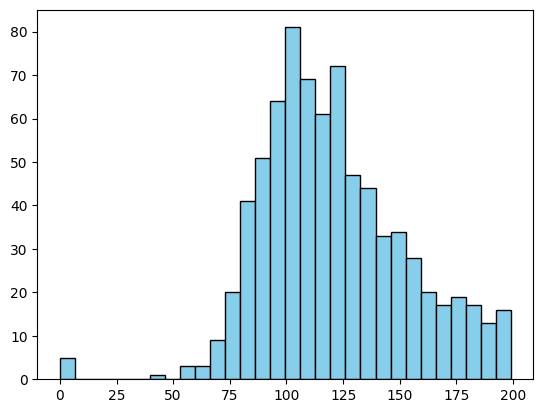

In [20]:
plt.hist(df['Glucose'], bins=30, color='skyblue', edgecolor='black')

In [21]:
print(df['Glucose'].eq(0).sum())

5


In [22]:
# data = ['BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [23]:
'''for col in data:
  replacing = df[col].replace(0, np.nan)
  median_values = replacing.median()
  df[col] = df[col].replace(0, median_values)'''

'for col in data:\n  replacing = df[col].replace(0, np.nan)\n  median_values = replacing.median()\n  df[col] = df[col].replace(0, median_values)'

(array([ 35.,   0.,   0.,   0.,   0.,   1.,   0.,   2.,   0.,   2.,   4.,
          7.,  24.,  25.,  58.,  85.,  75., 101.,  99.,  85.,  59.,  46.,
         30.,  11.,   6.,   3.,   5.,   3.,   1.,   1.]),
 array([  0.        ,   4.06666667,   8.13333333,  12.2       ,
         16.26666667,  20.33333333,  24.4       ,  28.46666667,
         32.53333333,  36.6       ,  40.66666667,  44.73333333,
         48.8       ,  52.86666667,  56.93333333,  61.        ,
         65.06666667,  69.13333333,  73.2       ,  77.26666667,
         81.33333333,  85.4       ,  89.46666667,  93.53333333,
         97.6       , 101.66666667, 105.73333333, 109.8       ,
        113.86666667, 117.93333333, 122.        ]),
 <BarContainer object of 30 artists>)

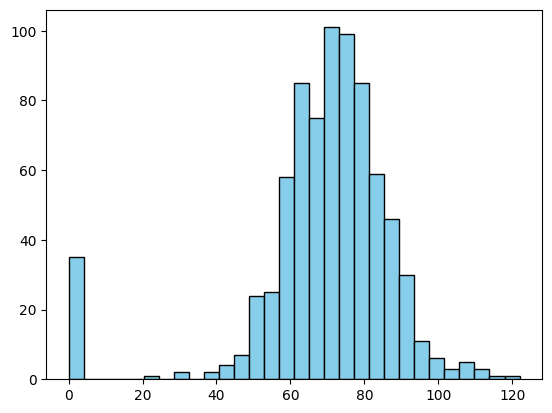

In [24]:
plt.hist(df['BloodPressure'], bins=30, color='skyblue', edgecolor='black')

A blood pressure of 0 is biologically impossible; therefore, these are treated as missing values


In [25]:
# Cleaning the data after visualizing the missing values (0s)
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_to_fix:
    df[col] = df[col].replace(0, np.nan)
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Ensure everything is back to numeric format
df[cols_to_fix] = df[cols_to_fix].apply(pd.to_numeric)

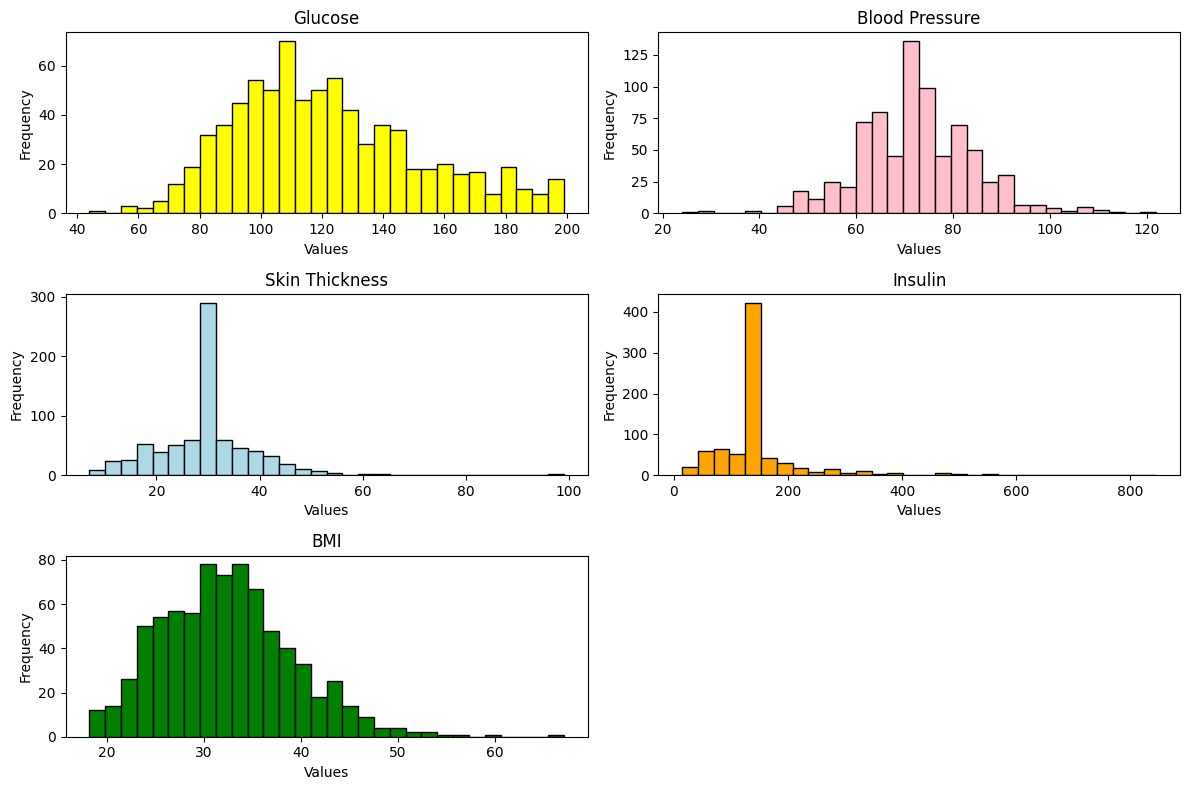

In [26]:
import matplotlib.pyplot as plt

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 8))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot each histogram
axes[0].hist(df["Glucose"], bins=30, color='yellow', edgecolor='black')
axes[0].set_title('Glucose')

axes[1].hist(df["BloodPressure"], bins=30, color='pink', edgecolor='black')
axes[1].set_title('Blood Pressure')

axes[2].hist(df["SkinThickness"], bins=30, color='lightblue', edgecolor='black')
axes[2].set_title('Skin Thickness')

axes[3].hist(df["Insulin"], bins=30, color='orange', edgecolor='black')
axes[3].set_title('Insulin')

axes[4].hist(df["BMI"], bins=30, color='green', edgecolor='black')
axes[4].set_title('BMI')

# (Optional) Turn off any unused subplot
axes[5].axis('off')

# Add common labels
for ax in axes[:-1]:
    ax.set_xlabel('Values')
    ax.set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()

<Axes: xlabel='Outcome'>

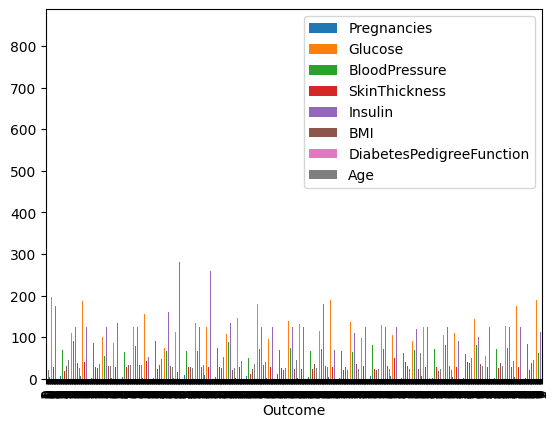

In [27]:
df.plot('Outcome', kind='bar')

<Axes: xlabel='Outcome'>

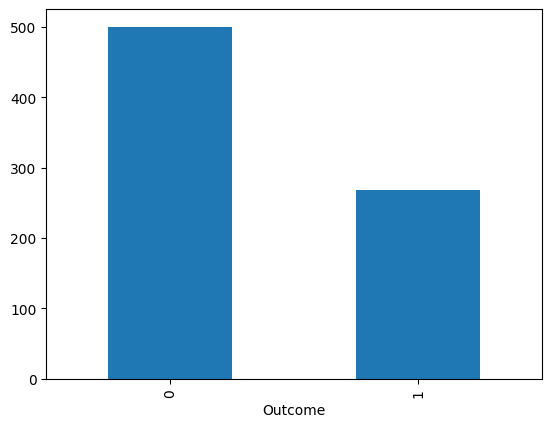

In [28]:
df['Outcome'].value_counts().plot(kind='bar')

In [29]:
dont_have = df[df.Outcome == 0]
have = df[df.Outcome == 1]

In [30]:
print(dont_have.shape)
print(have.shape)

(500, 9)
(268, 9)


In [31]:
dont_have_sample = dont_have.sample(n=268)

In [32]:
print(dont_have_sample.shape)

(268, 9)


In [33]:
df = pd.concat([dont_have_sample, have], axis = 0)

In [34]:
df['Outcome'].value_counts()

,count
Outcome,
0,268
1,268


In [35]:
corr = df.corr()
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.100940,0.183841,0.039484,0.007213,-0.001306,-0.032277,0.517150,0.225948
Glucose,0.100940,1.000000,0.213023,0.199375,0.400332,0.245370,0.126532,0.255753,0.493825
BloodPressure,0.183841,0.213023,1.000000,0.156556,0.006368,0.291240,-0.007168,0.315459,0.201857
SkinThickness,0.039484,0.199375,0.156556,1.000000,0.125983,0.521560,0.136198,0.087161,0.244660
Insulin,0.007213,0.400332,0.006368,0.125983,1.000000,0.147938,0.101256,0.086345,0.162500
BMI,-0.001306,0.245370,0.291240,0.521560,0.147938,1.000000,0.154298,0.000849,0.318401
DiabetesPedigreeFunction,-0.032277,0.126532,-0.007168,0.136198,0.101256,0.154298,1.000000,0.010724,0.141703
Age,0.517150,0.255753,0.315459,0.087161,0.086345,0.000849,0.010724,1.000000,0.273360
Outcome,0.225948,0.493825,0.201857,0.244660,0.162500,0.318401,0.141703,0.273360,1.000000


<Axes: >

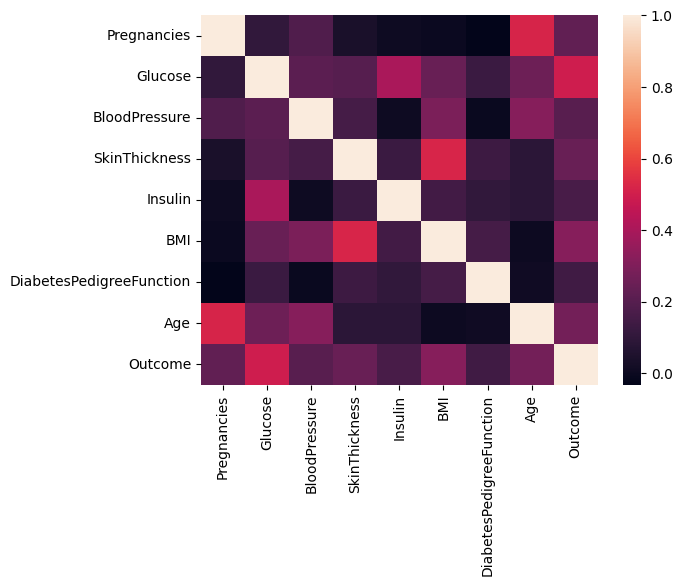

In [36]:
sns.heatmap(corr)

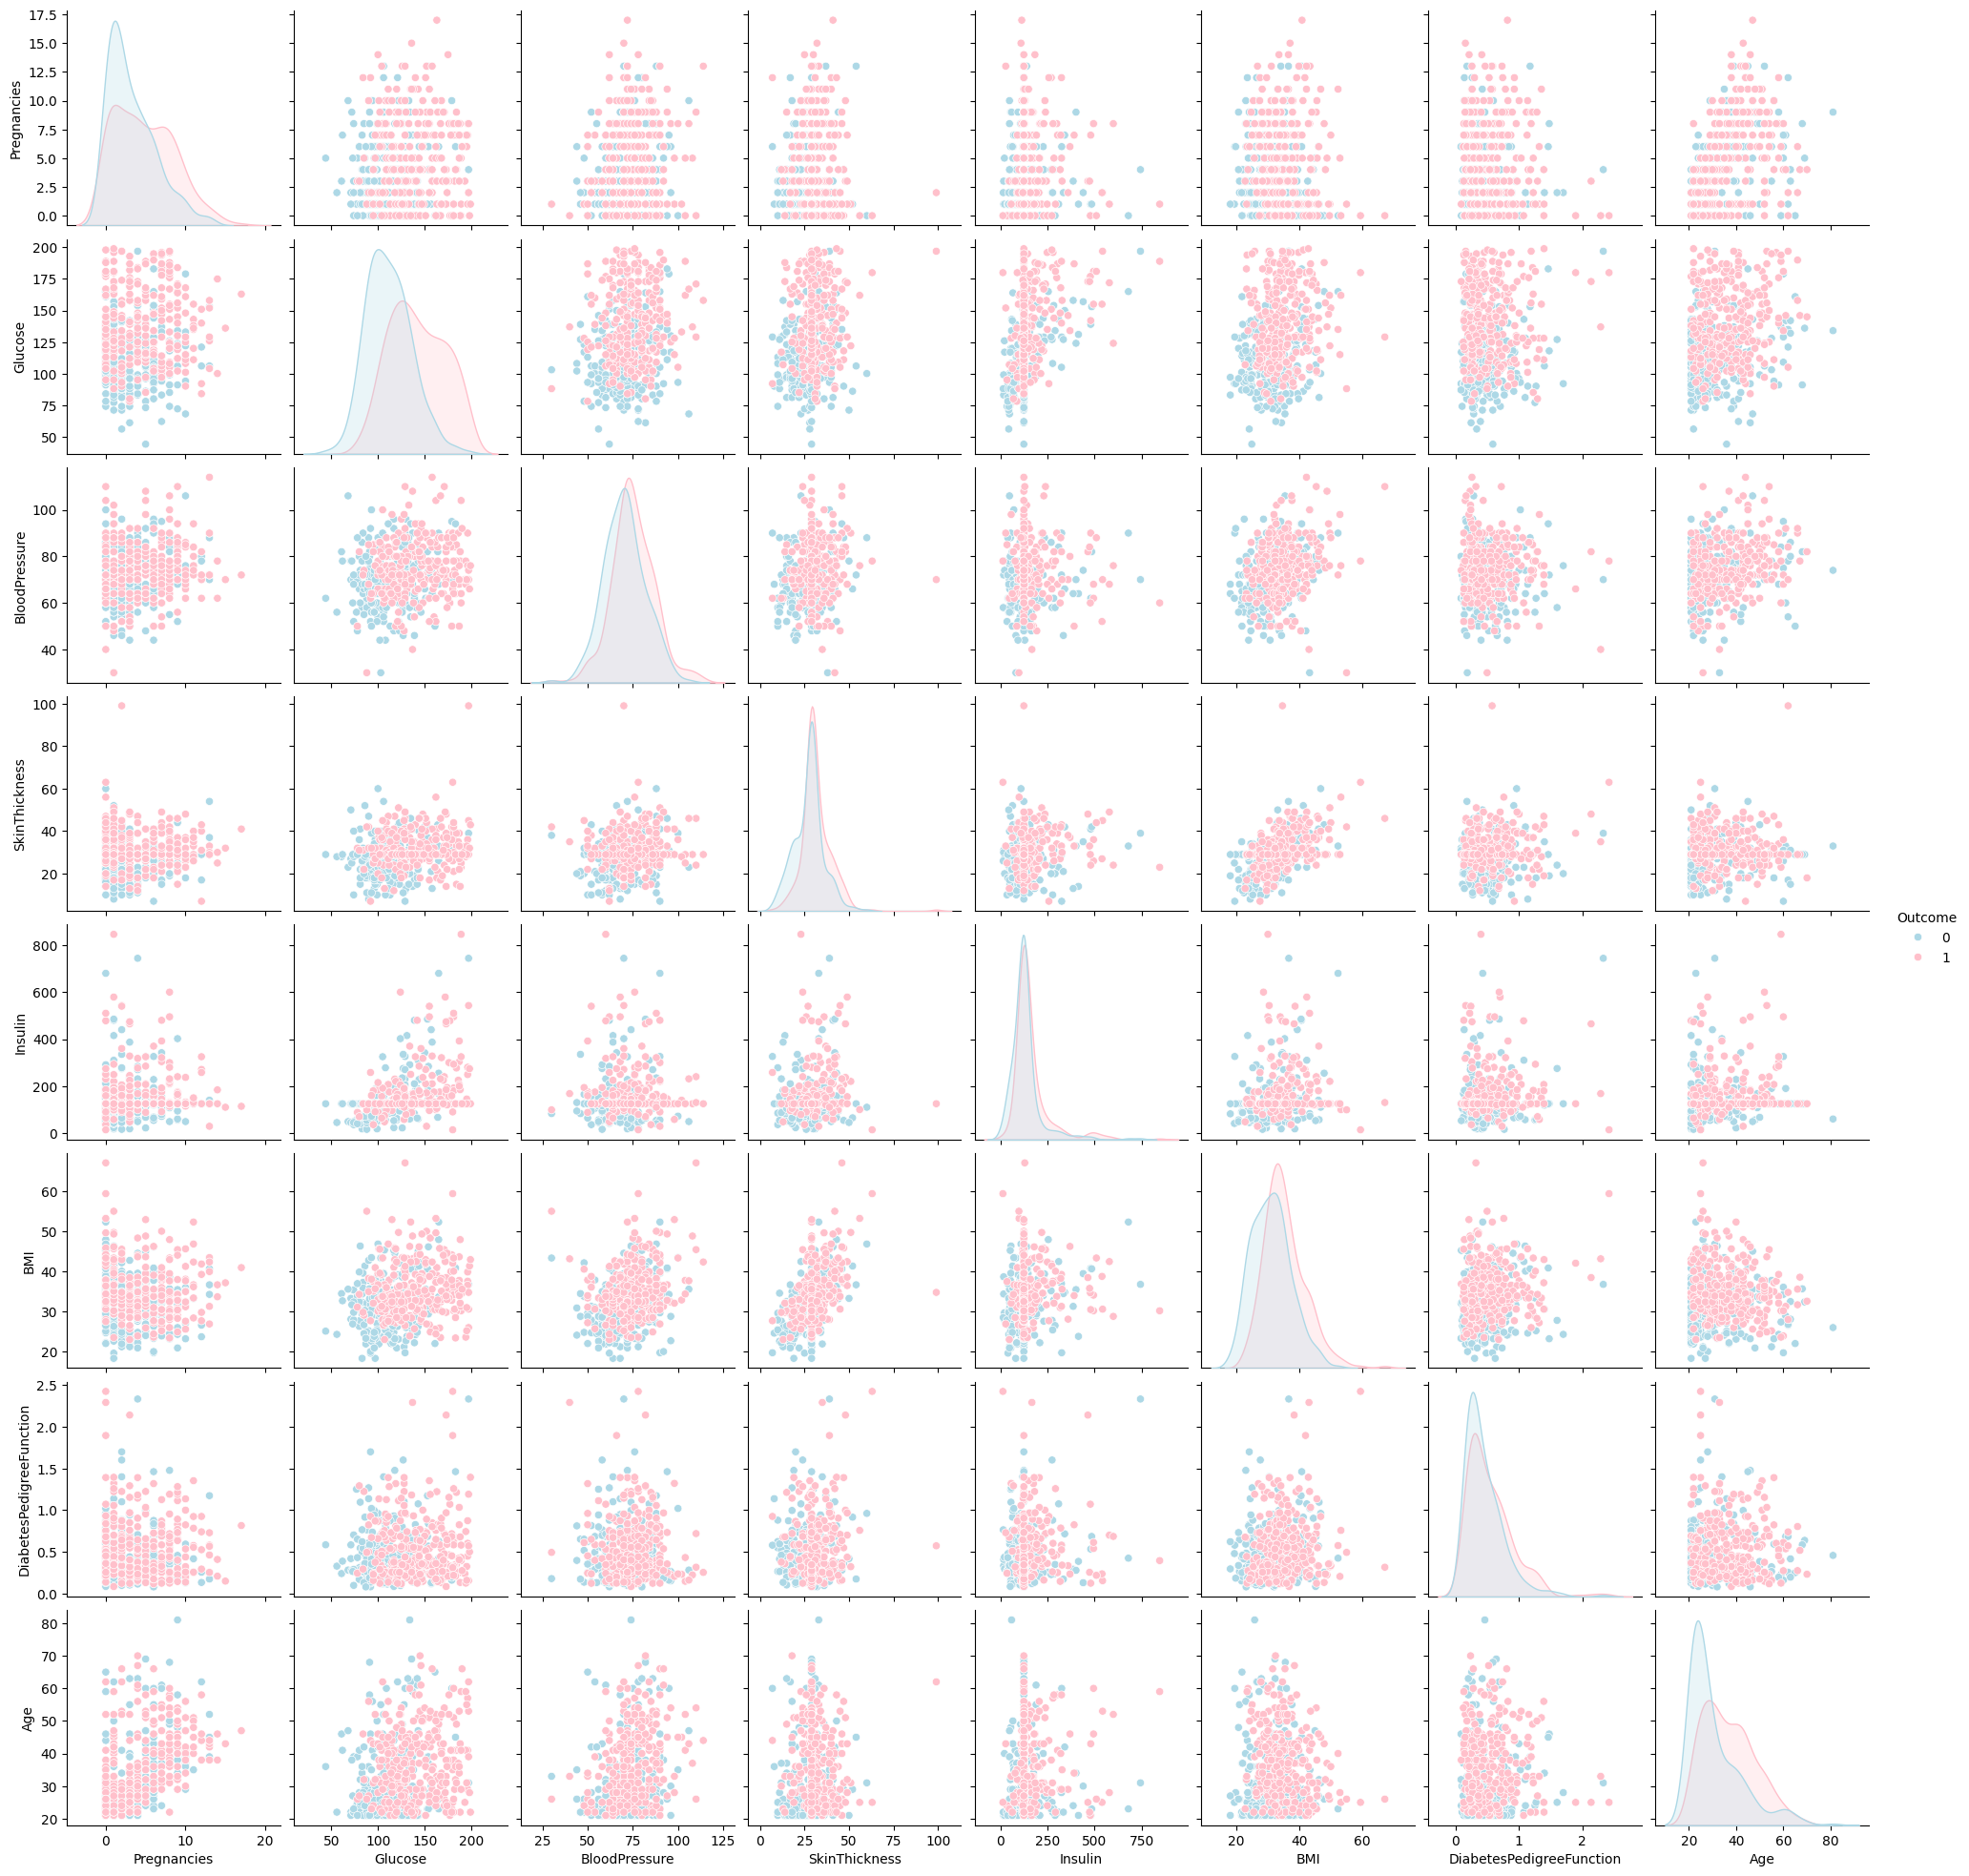

In [37]:
custom_palette = {0: 'lightblue', 1: 'pink'}
sns.pairplot(df, hue='Outcome', palette=custom_palette)
plt.show()

In [38]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
747,1,81.0,74.0,41.0,57.0,46.3,1.096,32,0
5,5,116.0,74.0,29.0,125.0,25.6,0.201,30,0
139,5,105.0,72.0,29.0,325.0,36.9,0.159,28,0
564,0,91.0,80.0,29.0,125.0,32.4,0.601,27,0
18,1,103.0,30.0,38.0,83.0,43.3,0.183,33,0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536 entries, 747 to 766
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               536 non-null    int64  
 1   Glucose                   536 non-null    float64
 2   BloodPressure             536 non-null    float64
 3   SkinThickness             536 non-null    float64
 4   Insulin                   536 non-null    float64
 5   BMI                       536 non-null    float64
 6   DiabetesPedigreeFunction  536 non-null    float64
 7   Age                       536 non-null    int64  
 8   Outcome                   536 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 41.9 KB


Handling Outliers

In [40]:
data = df.drop("Outcome", axis=1)

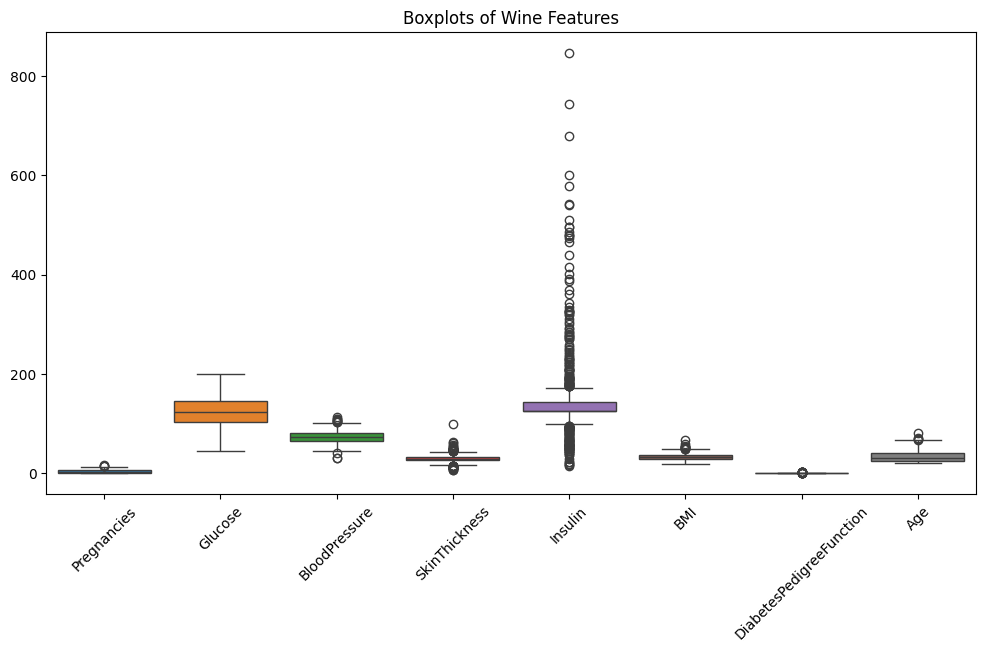

In [41]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.title("Boxplots of Wine Features")
plt.show()

In [42]:
'''# Compute IQR bounds per column
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Extract the specific bounds for 'BloodPressure'
lower_bp = Q1['BloodPressure'] - 1.5 * IQR['BloodPressure']
upper_bp = Q3['BloodPressure'] + 1.5 * IQR['BloodPressure']

# Convert to numeric (if not already)
df['BloodPressure'] = pd.to_numeric(df['BloodPressure'], errors='coerce')

# Clip only using the BloodPressure bounds
df['BloodPressure'] = np.clip(df['BloodPressure'], lower_bp, upper_bp)

print("Data after Capping Outliers:\n", df['BloodPressure'].head())
'''

'# Compute IQR bounds per column\nQ1 = data.quantile(0.25)\nQ3 = data.quantile(0.75)\nIQR = Q3 - Q1\n\n# Extract the specific bounds for \'BloodPressure\'\nlower_bp = Q1[\'BloodPressure\'] - 1.5 * IQR[\'BloodPressure\']\nupper_bp = Q3[\'BloodPressure\'] + 1.5 * IQR[\'BloodPressure\']\n\n# Convert to numeric (if not already)\ndf[\'BloodPressure\'] = pd.to_numeric(df[\'BloodPressure\'], errors=\'coerce\')\n\n# Clip only using the BloodPressure bounds\ndf[\'BloodPressure\'] = np.clip(df[\'BloodPressure\'], lower_bp, upper_bp)\n\nprint("Data after Capping Outliers:\n", df[\'BloodPressure\'].head())\n'

In [43]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

upper_preg = Q3['Pregnancies'] + 1.5 * IQR['Pregnancies']
lower_preg = Q1['Pregnancies'] - 1.5 * IQR['Pregnancies']

# Display outliers
df[df['Pregnancies'] > upper_preg]['Pregnancies']


,Pregnancies
88,15
159,17
298,14
455,14


In [44]:
cols_to_cap = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction', 'BMI']

In [45]:
# Compute IQR for all columns
Q1 = df[cols_to_cap].quantile(0.25)
Q3 = df[cols_to_cap].quantile(0.75)
IQR = Q3 - Q1

# Loop through each column to cap outliers
for col in cols_to_cap:
    lower_bound = Q1[col] - 1.5 * IQR[col]
    upper_bound = Q3[col] + 1.5 * IQR[col]
    df[col] = np.clip(df[col], lower_bound, upper_bound)

print("Outliers capped successfully for selected columns!")

Outliers capped successfully for selected columns!


In [46]:
print("Data after Capping Outliers:\n", df)

Data after Capping Outliers:
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
747          1.0     81.0           74.0           41.0     96.5  46.3   
5            5.0    116.0           74.0           29.0    125.0  25.6   
139          5.0    105.0           72.0           29.0    172.5  36.9   
564          0.0     91.0           80.0           29.0    125.0  32.4   
18           1.0    103.0           42.5           38.0     96.5  43.3   
..           ...      ...            ...            ...      ...   ...   
755          1.0    128.0           88.0           39.0    110.0  36.5   
757          0.0    123.0           72.0           29.0    125.0  36.3   
759          6.0    190.0           92.0           29.0    125.0  35.5   
761          9.0    170.0           74.0           31.0    125.0  44.0   
766          1.0    126.0           60.0           29.0    125.0  30.1   

     DiabetesPedigreeFunction  Age  Outcome  
747                     1.096   32 

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536 entries, 747 to 766
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               536 non-null    float64
 1   Glucose                   536 non-null    float64
 2   BloodPressure             536 non-null    float64
 3   SkinThickness             536 non-null    float64
 4   Insulin                   536 non-null    float64
 5   BMI                       536 non-null    float64
 6   DiabetesPedigreeFunction  536 non-null    float64
 7   Age                       536 non-null    int64  
 8   Outcome                   536 non-null    int64  
dtypes: float64(7), int64(2)
memory usage: 41.9 KB


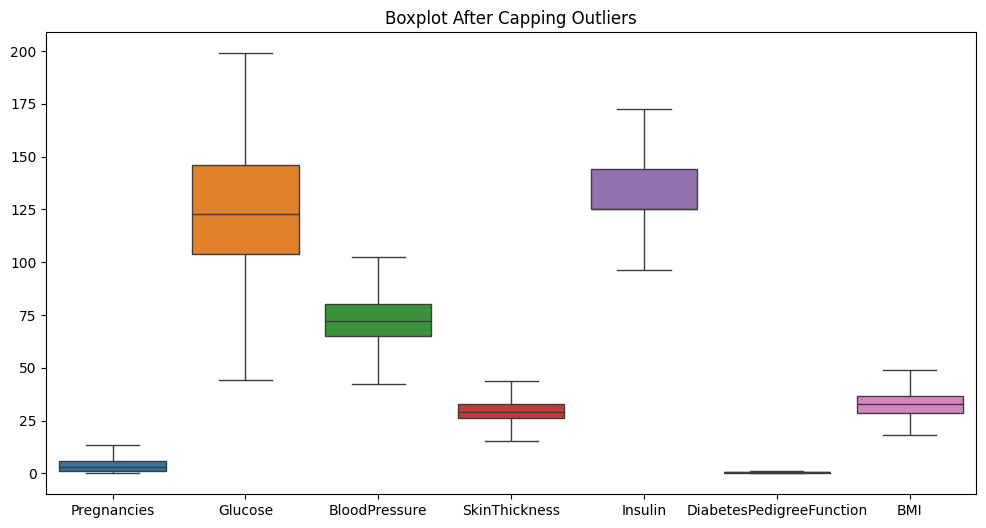

In [48]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_to_cap])
plt.title("Boxplot After Capping Outliers")
plt.show()

In [49]:
df['insulin_glucose_ratio'] = df['Insulin'] / df['Glucose']

In [50]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,insulin_glucose_ratio
747,1.0,81.0,74.0,41.0,96.5,46.3,1.096,32,0,1.191358
5,5.0,116.0,74.0,29.0,125.0,25.6,0.201,30,0,1.077586
139,5.0,105.0,72.0,29.0,172.5,36.9,0.159,28,0,1.642857
564,0.0,91.0,80.0,29.0,125.0,32.4,0.601,27,0,1.373626
18,1.0,103.0,42.5,38.0,96.5,43.3,0.183,33,0,0.936893


In [51]:
# Create numeric BMI categories
bins = [0, 25, 30, float('inf')]
labels = [0, 1, 2]   # 0 = normal, 1 = overweight, 2 = obese

df['bmi_category'] = pd.cut(df['BMI'], bins=bins, labels=labels, right=False)

# Verify distribution
print(df['bmi_category'].value_counts())

bmi_category
2    367
1    112
0     57
Name: count, dtype: int64


In [52]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,insulin_glucose_ratio,bmi_category
747,1.0,81.0,74.0,41.0,96.5,46.3,1.096,32,0,1.191358,2
5,5.0,116.0,74.0,29.0,125.0,25.6,0.201,30,0,1.077586,1
139,5.0,105.0,72.0,29.0,172.5,36.9,0.159,28,0,1.642857,2
564,0.0,91.0,80.0,29.0,125.0,32.4,0.601,27,0,1.373626,2
18,1.0,103.0,42.5,38.0,96.5,43.3,0.183,33,0,0.936893,2


In [53]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0
insulin_glucose_ratio,0


In [54]:
df.dropna(subset=['Glucose','insulin_glucose_ratio'], inplace=True)

In [55]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0
insulin_glucose_ratio,0


In [56]:
x = df.drop(columns='Outcome', axis=True)

In [57]:
y = df['Outcome']

In [58]:
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,insulin_glucose_ratio,bmi_category
747,1.0,81.0,74.0,41.0,96.5,46.3,1.096,32,1.191358,2
5,5.0,116.0,74.0,29.0,125.0,25.6,0.201,30,1.077586,1
139,5.0,105.0,72.0,29.0,172.5,36.9,0.159,28,1.642857,2
564,0.0,91.0,80.0,29.0,125.0,32.4,0.601,27,1.373626,2
18,1.0,103.0,42.5,38.0,96.5,43.3,0.183,33,0.936893,2


In [59]:
y.head()

,Outcome
747,0
5,0
139,0
564,0
18,0


In [60]:
# Create interaction features
df['Glucose_Age'] = df['Glucose'] * df['Age']
df['BMI_Insulin'] = df['BMI'] * df['Insulin']


In [119]:
# Create new medical indicators that are highly correlated with Diabetes
# 1. Glucose and Age interaction (Risk increases with both)
df['Glucose_Age'] = df['Glucose'] * df['Age']

# 2. Body Mass Index and Blood Pressure interaction
df['BMI_BP'] = df['BMI'] * df['BloodPressure']

# 3. Insulin and Glucose (The metabolic relationship)
df['Metabolic_Index'] = df['Insulin'] * df['Glucose']

# Update your feature list to include these new columns
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
            'BMI', 'DiabetesPedigreeFunction', 'Age', 'Glucose_Age', 'BMI_BP', 'Metabolic_Index']

In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# We scale only the feature columns, not the 'Outcome'
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
df[features] = scaler.fit_transform(df[features])

print("Features have been standardized. Accuracy should improve for KNN and SVM.")

Features have been standardized. Accuracy should improve for KNN and SVM.


Split the data into train and test

In [121]:
from sklearn.model_selection import train_test_split

In [122]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0,
                                                    test_size=0.2)

In [123]:
# scaling data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [124]:
x_train.shape

(428, 10)

In [125]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)

LogisticRegression()

In [126]:
y_pred = log_reg.predict(x_test)

In [127]:
y_pred

array([0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0])

In [128]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, log_reg.predict(x_train)))
log_reg_acc = accuracy_score(y_test, log_reg.predict(x_test))
print(log_reg_acc)

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

0.7780373831775701
0.7407407407407407
[[40 12]
 [16 40]]
              precision    recall  f1-score   support

           0       0.71      0.77      0.74        52
           1       0.77      0.71      0.74        56

    accuracy                           0.74       108
   macro avg       0.74      0.74      0.74       108
weighted avg       0.74      0.74      0.74       108



KNeighborsClassifier

In [129]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [130]:
y_pred = knn.predict(x_test)

In [131]:
y_pred

array([0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0])

In [132]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, knn.predict(x_train)))
knn_acc = accuracy_score(y_test, knn.predict(x_test))
print(knn_acc)

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

0.8271028037383178
0.6851851851851852
[[35 17]
 [17 39]]
              precision    recall  f1-score   support

           0       0.67      0.67      0.67        52
           1       0.70      0.70      0.70        56

    accuracy                           0.69       108
   macro avg       0.68      0.68      0.68       108
weighted avg       0.69      0.69      0.69       108



In [133]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc= SVC(probability=True)

parameters = {
    'gamma': [0.0001, 0.001, 0.01, 0.1],
    'C':[0.01, 0.05, 0.5, 0.1, 1, 10, 15,20]
}
grid_search = GridSearchCV(svc, parameters)
grid_search.fit(x_train, y_train)

GridSearchCV(estimator=SVC(probability=True),
             param_grid={'C': [0.01, 0.05, 0.5, 0.1, 1, 10, 15, 20],
                         'gamma': [0.0001, 0.001, 0.01, 0.1]})

In [134]:

grid_search.best_params_

{'C': 1, 'gamma': 0.1}

In [135]:
grid_search.best_score_

np.float64(0.7567989056087551)

In [136]:
svc = SVC(C=0.5, gamma=0.1, probability=True)
svc.fit(x_train, y_train)

SVC(C=0.5, gamma=0.1, probability=True)

In [137]:
y_pred =svc.predict(x_test)

In [138]:
y_pred

array([0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0])

In [139]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, svc.predict(x_train)))
svc_acc = accuracy_score(y_test, svc.predict(x_test))
print(svc_acc)

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

0.8247663551401869
0.7129629629629629
[[36 16]
 [15 41]]
              precision    recall  f1-score   support

           0       0.71      0.69      0.70        52
           1       0.72      0.73      0.73        56

    accuracy                           0.71       108
   macro avg       0.71      0.71      0.71       108
weighted avg       0.71      0.71      0.71       108



In [140]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()

parameters ={
    'criterion':['gini','entropy'],
    'max_depth':range(2,32,1),
    'min_samples_leaf':range(1,10,1),
    'min_samples_split':range(2,10,1),
    'splitter':['best','random']
}

grid_search_dt = GridSearchCV(dtc, parameters, cv=5, n_jobs=-1, verbose=1)
grid_search_dt.fit(x_train, y_train)

Fitting 5 folds for each of 8640 candidates, totalling 43200 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(2, 32),
                         'min_samples_leaf': range(1, 10),
                         'min_samples_split': range(2, 10),
                         'splitter': ['best', 'random']},
             verbose=1)

In [141]:
grid_search_dt.best_params_

{'criterion': 'entropy',
 'max_depth': 22,
 'min_samples_leaf': 9,
 'min_samples_split': 4,
 'splitter': 'random'}

In [142]:
grid_search_dt.best_score_

np.float64(0.7614227086183311)

In [143]:
dtc = DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_leaf=8, min_samples_split=2, splitter='random')

In [144]:
dtc.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_leaf=8,
                       splitter='random')

In [145]:
y_pred =dtc.predict(x_test)

In [146]:
y_pred

array([0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0])

In [147]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, dtc.predict(x_train)))
dtc_acc = accuracy_score(y_test, dtc.predict(x_test))
print(dtc_acc)

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

0.7546728971962616
0.6018518518518519
[[29 23]
 [20 36]]
              precision    recall  f1-score   support

           0       0.59      0.56      0.57        52
           1       0.61      0.64      0.63        56

    accuracy                           0.60       108
   macro avg       0.60      0.60      0.60       108
weighted avg       0.60      0.60      0.60       108



In [148]:
from sklearn.ensemble import RandomForestClassifier

rand_clf= RandomForestClassifier(criterion= 'entropy', max_depth = 10, max_features = 0.5, min_samples_leaf=2, min_samples_split=3, n_estimators=130)
rand_clf.fit(x_train, y_train)
from sklearn.model_selection import RandomizedSearchCV

# 1. Define the parameters to test
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 2. Search for the best settings using the model you already created (rand_clf)
rf_random = RandomizedSearchCV(estimator=rand_clf,
                               param_distributions=param_grid,
                               n_iter=10, cv=5, verbose=0, random_state=42)
rf_random.fit(x_train, y_train)

# 3. Get the new improved accuracy
best_rf_model = rf_random.best_estimator_
# Calculate the accuracy score using your test data (x_test, y_test)
# If you only have train data for now, use x_train, y_train
best_rf_acc = best_rf_model.score(x_test, y_test)

print(f"Improved Random Forest Accuracy: {best_rf_acc * 100:.2f}%")

Improved Random Forest Accuracy: 71.30%


In [149]:
y_pred = best_rf_model.predict(x_test)

In [150]:
y_pred

array([0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0])

In [151]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, best_rf_model.predict(x_train)))
rand_clf_acc = accuracy_score(y_test, y_pred)
print(rand_clf_acc)
y_pred = rand_clf.predict(x_test)
print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

0.9742990654205608
0.7129629629629629
[[38 14]
 [17 39]]
              precision    recall  f1-score   support

           0       0.69      0.73      0.71        52
           1       0.74      0.70      0.72        56

    accuracy                           0.71       108
   macro avg       0.71      0.71      0.71       108
weighted avg       0.71      0.71      0.71       108



In [152]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier()

parameters = {
    'loss': ['deviance', 'exponential'],
    'learning_rate': [0.001, 0.1],
    'n_estimators': [100, 150, 180]
}

grid_search_gbc = GridSearchCV(gbc, parameters, cv = 2, n_jobs = -5, verbose = 1)
grid_search_gbc.fit(x_train, y_train)

Fitting 2 folds for each of 12 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
12 fits failed out of a total of 24.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

GridSearchCV(cv=2, estimator=GradientBoostingClassifier(), n_jobs=-5,
             param_grid={'learning_rate': [0.001, 0.1],
                         'loss': ['deviance', 'exponential'],
                         'n_estimators': [100, 150, 180]},
             verbose=1)

In [153]:
grid_search_gbc.best_params_

{'learning_rate': 0.1, 'loss': 'exponential', 'n_estimators': 180}

In [154]:
grid_search_gbc.best_score_

np.float64(0.7406542056074766)

In [155]:
gbc = GradientBoostingClassifier(learning_rate=0.1, loss='exponential', n_estimators=100)
gbc.fit(x_train, y_train)

GradientBoostingClassifier(loss='exponential')

In [156]:
y_pred = gbc.predict(x_test)

In [157]:
y_pred

array([0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0])

In [158]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, gbc.predict(x_train)))
gbc_acc = accuracy_score(y_test, gbc.predict(x_test))
print(gbc_acc)
y_pred = gbc.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


0.9369158878504673
0.7037037037037037
[[37 15]
 [17 39]]
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        52
           1       0.72      0.70      0.71        56

    accuracy                           0.70       108
   macro avg       0.70      0.70      0.70       108
weighted avg       0.70      0.70      0.70       108



In [159]:
from xgboost import XGBClassifier

xgb = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.01, max_depth = 5, n_estimators = 180)

xgb.fit(x_train, y_train)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

# 1. Define the parameters for XGBoost optimization
xgb_params = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

# 2. Search for the best settings
# Note: 'xgb' is the model variable name currently in your notebook
xgb_search = RandomizedSearchCV(xgb, param_distributions=xgb_params, n_iter=10, cv=5, random_state=42)
xgb_search.fit(x_train, y_train)

# 3. Get the improved model and update the accuracy variable
best_xgb_model = xgb_search.best_estimator_
xgb_acc = accuracy_score(y_test, best_xgb_model.predict(x_test))

print(f"New Optimized XGBoost Accuracy: {xgb_acc * 100:.2f}%")

New Optimized XGBoost Accuracy: 75.00%


In [160]:
y_pred = best_xgb_model.predict(x_test)

In [161]:

y_pred

array([0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0])

In [162]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Training Accuracy of the optimized model
print(f"Training Accuracy: {accuracy_score(y_train, best_xgb_model.predict(x_train))}")

# Testing Accuracy for the final table
xgb_acc = accuracy_score(y_test, y_pred)
print(f"Testing Accuracy: {xgb_acc}")

# Detailed Metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Accuracy: 0.8551401869158879
Testing Accuracy: 0.75
Confusion Matrix:
[[41 11]
 [16 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75        52
           1       0.78      0.71      0.75        56

    accuracy                           0.75       108
   macro avg       0.75      0.75      0.75       108
weighted avg       0.75      0.75      0.75       108



In [163]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree Classifier',
              'Random Forest Classifier', 'Gradient Boosting Classifier', 'XGBoost'],
    'Score': [
        100*round(log_reg_acc, 4),
        100*round(knn_acc, 4),
        100*round(svc_acc, 4),
        100*round(dtc_acc, 4),
        100*round(best_rf_acc, 4),   # Changed from rand_clf_acc
        100*round(gbc_acc, 4),
        100*round(xgb_acc, 4)        # Ensure this is your optimized xgb_acc
    ]
})

models.sort_values(by='Score', ascending=False)

,Model,Score
6,XGBoost,75.00
0,Logistic Regression,74.07
2,SVM,71.30
4,Random Forest Classifier,71.30
5,Gradient Boosting Classifier,70.37
1,KNN,68.52
3,Decision Tree Classifier,60.19


/tmp/ipykernel_682/388964688.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Model', data=models, palette='viridis')


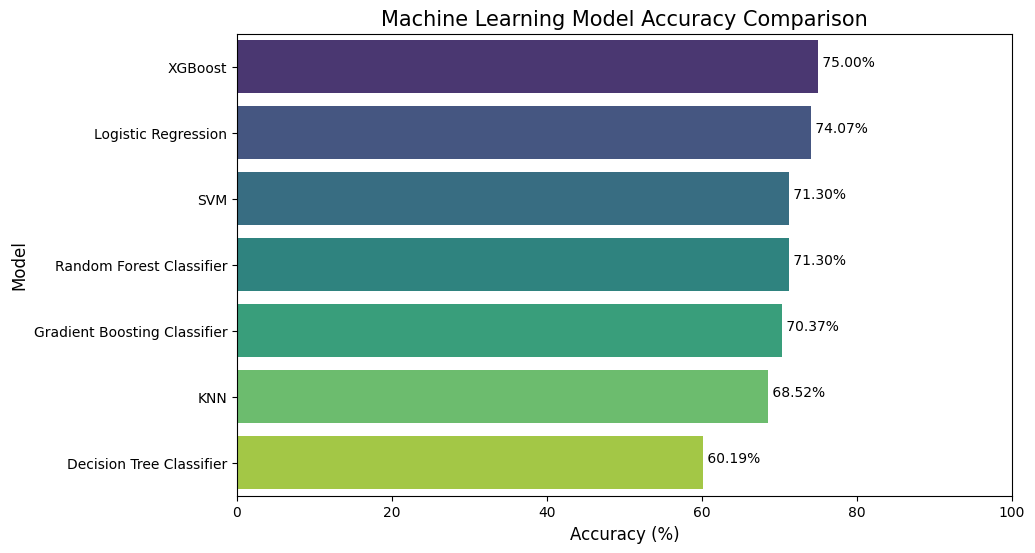

In [164]:
# Sort models by score for a better looking chart
models = models.sort_values(by='Score', ascending=False)

# Create the visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Score', y='Model', data=models, palette='viridis')

# Add labels and title
plt.title('Machine Learning Model Accuracy Comparison', fontsize=15)
plt.xlabel('Accuracy (%)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0, 100) # Ensure scale is 0-100%

# Add text labels on the bars
for index, value in enumerate(models.Score):
    plt.text(value, index, f' {value:.2f}%')

plt.show()